____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [13]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [14]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2kmnaive', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

_______
# Surface

In [15]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True)

# Closure figs
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()

#df['Pressure gradient'] = ['L3-250m-SWOT', 'L3-2km-SWOT','L4-regional-noSWOT','L4-global-noSWOT', 'L4-SWOT',]
#df = df.reset_index().set_index('Pressure gradient')






nofilter__swot2kmnaive_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed


In [84]:
DSS

<xarray.Dataset> Size: 62MB
Dimensions:        (id_comb: 1, row_number: 150948)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 1MB 2023-04-01T11:50:...
    longitude      (id_comb, row_number) float64 1MB 5.538 5.539 ... 2.014 2.012
    latitude       (id_comb, row_number) float64 1MB 42.31 42.31 ... 41.06 41.06
    pass_number    (id_comb, row_number) int64 1MB 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot   (id_comb, row_number) timedelta64[ns] 1MB 11:52:32.696536 ...
    cycle_number   (id_comb, row_number) int64 1MB 478 478 478 ... 577 577 577
    drifter_id     (id_comb, row_number) object 1MB '0-4351296' ... '295'
    drifter_type   (id_comb, row_number) object 1MB 'CARTHE' ... 'HEREON'
    depth          (id_comb, row_number) int64 1MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    phi            (id_comb, row_number) float64 1MB 0.2477 0.2478 ... 2.91 2.91
  * row_number     (row_number) int64 1MB 144 145 146 ... 376432 376433 376434
  * id_comb        (id_comb) <U38 152B 'nofilter__swot2kmnaive_etaf__rio_0era5'
Data variables: (12/40)
    sume           (id_comb, row_number) float64 1MB -2.366e-05 ... -1.384e-05
    acce           (id_comb, row_number) float64 1MB -7.905e-06 ... -8.778e-06
    exce_acc       (id_comb, row_number) float64 1MB -1.575e-05 ... -5.064e-06
    core           (id_comb, row_number) float64 1MB 1.226e-05 ... 1.516e-05
    exce_cor       (id_comb, row_number) float64 1MB -3.592e-05 ... -2.9e-05
    ggde           (id_comb, row_number) float64 1MB 9.618e-07 ... -1.727e-05
    ...             ...
    D_cyclo        (id_comb, row_number) float64 1MB 8.383e-11 ... 6.084e-10
    D_anticyclo    (id_comb, row_number) float64 1MB 1.879e-10 ... 1.477e-09
    tote           (id_comb, row_number) float64 1MB 1.054e-09 ... 6.138e-10
    totn           (id_comb, row_number) float64 1MB 3.909e-10 ... 6.977e-10
    DD_cyclo       (id_comb, row_number) float64 1MB 0.05803 0.06344 ... 0.4639
    DD_anticyclo   (id_comb, row_number) float64 1MB 0.1301 0.1334 ... 1.126

In [65]:
for direction in ['e', 'n']:
    DSS['D'+direction+'_cyclo'] = -2 *(DSS['acc'+direction]+DSS['cor'+direction])*DSS['ggd'+direction]
    DSS['D'+direction+'_anticyclo'] = -2 *(DSS['acc'+direction]+DSS['ggd'+direction])*DSS['cor'+direction]

DSS['D_cyclo'] = DSS['De_cyclo']+DSS['Dn_cyclo']
DSS['D_anticyclo'] = DSS['De_anticyclo']+DSS['Dn_anticyclo']

DSS['tote'] = DSS['acce']**2 + DSS['core']**2+ DSS['ggde']**2 + DSS['wde']**2
DSS['totn'] = DSS['accn']**2 + DSS['corn']**2+ DSS['ggdn']**2 + DSS['wdn']**2

DSS['DD_cyclo'] = DSS['D_cyclo']/(DSS.tote+DSS.totn)
DSS['DD_anticyclo'] = DSS['D_anticyclo']/(DSS.tote+DSS.totn)

dff = DSS.to_dataframe().reset_index().set_index('row_number')

<Axes: ylabel='Frequency'>

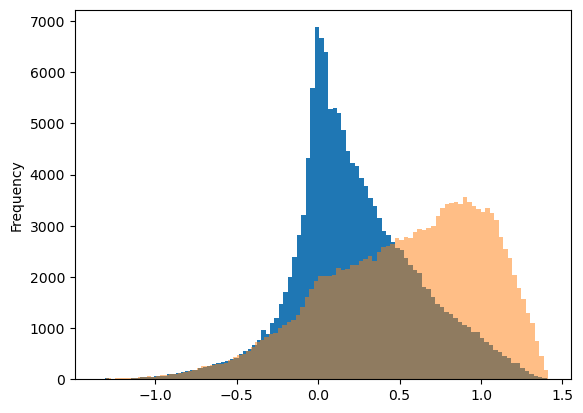

In [81]:
dff.DD_cyclo.plot.hist(bins=100)
dff.DD_anticyclo.plot.hist(bins=100, alpha=0.5)

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_59088/1346031834.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


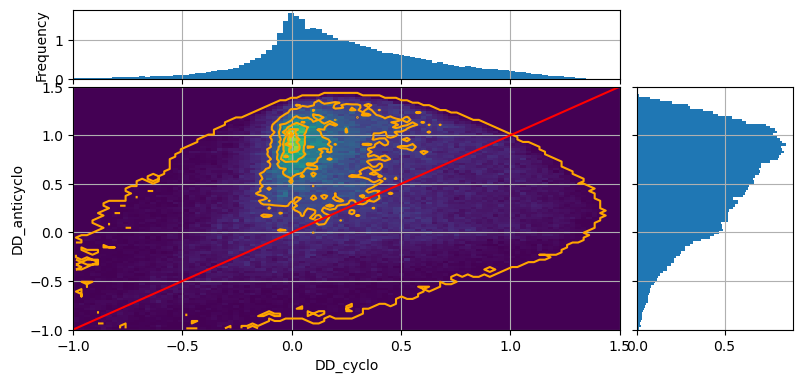

In [86]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    
    da.plot(ax=ax, add_colorbar=False)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

    

plot_join_pdfs(dff, 'DD_cyclo', 'DD_anticyclo', binx=np.linspace(-1, 1.5,100), biny=np.linspace(-1, 1.5,100))

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_59088/3769472447.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(15,6))


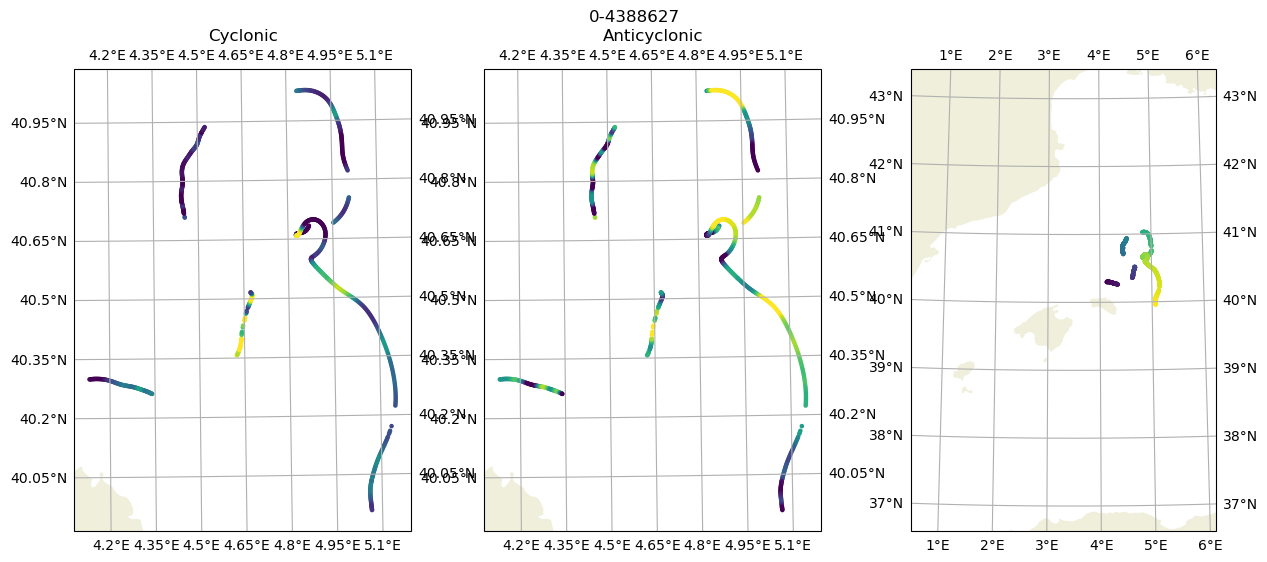

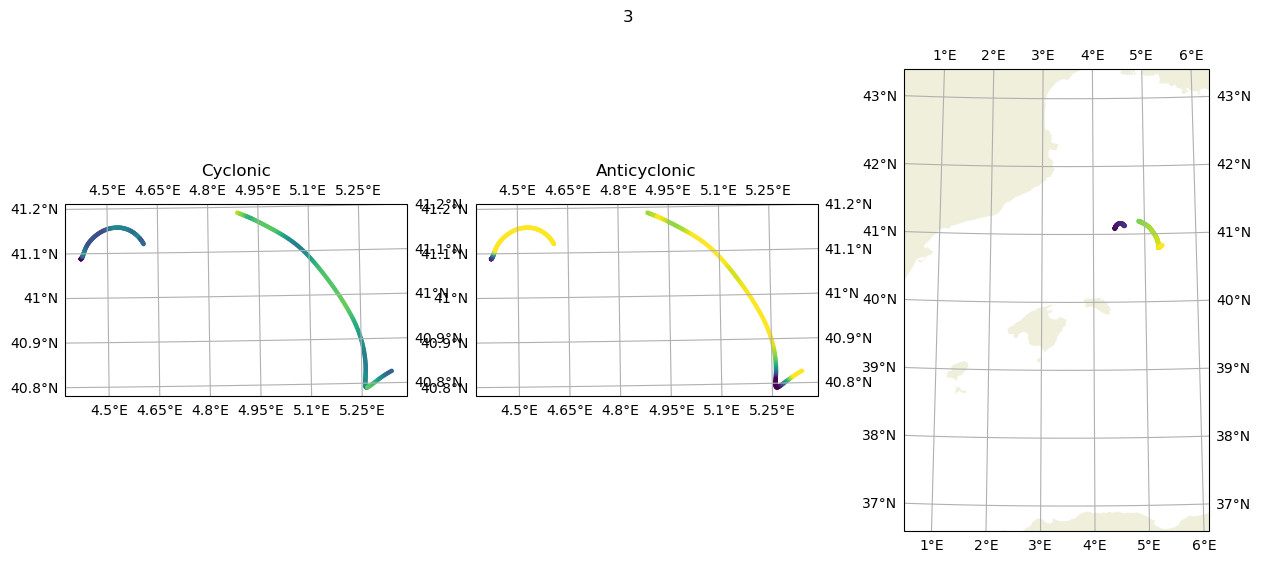

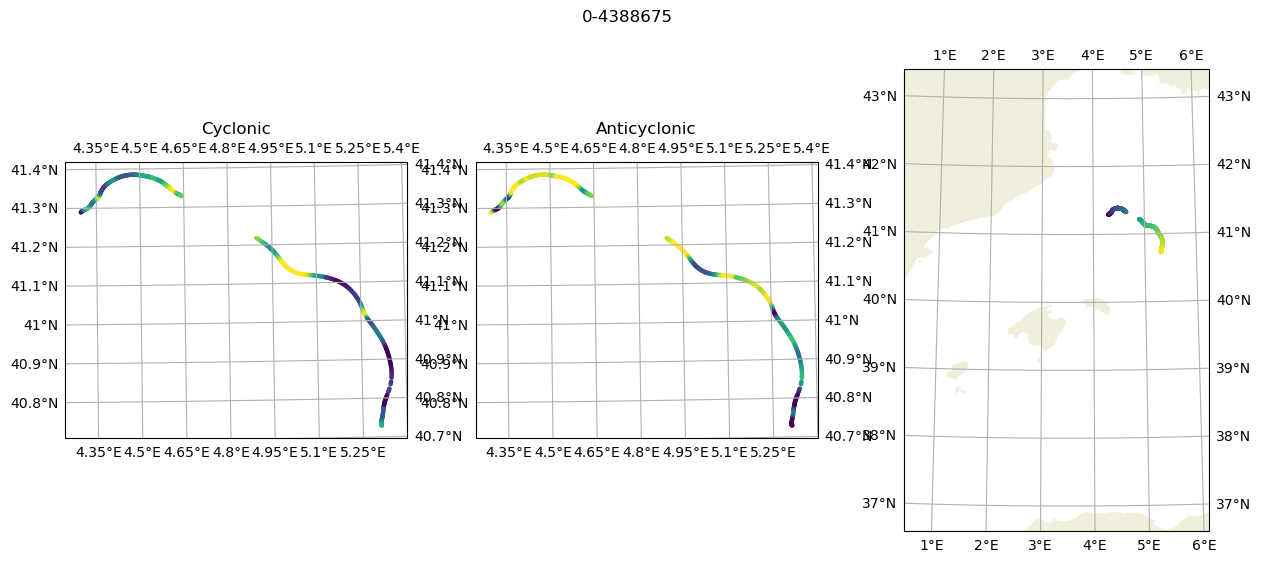

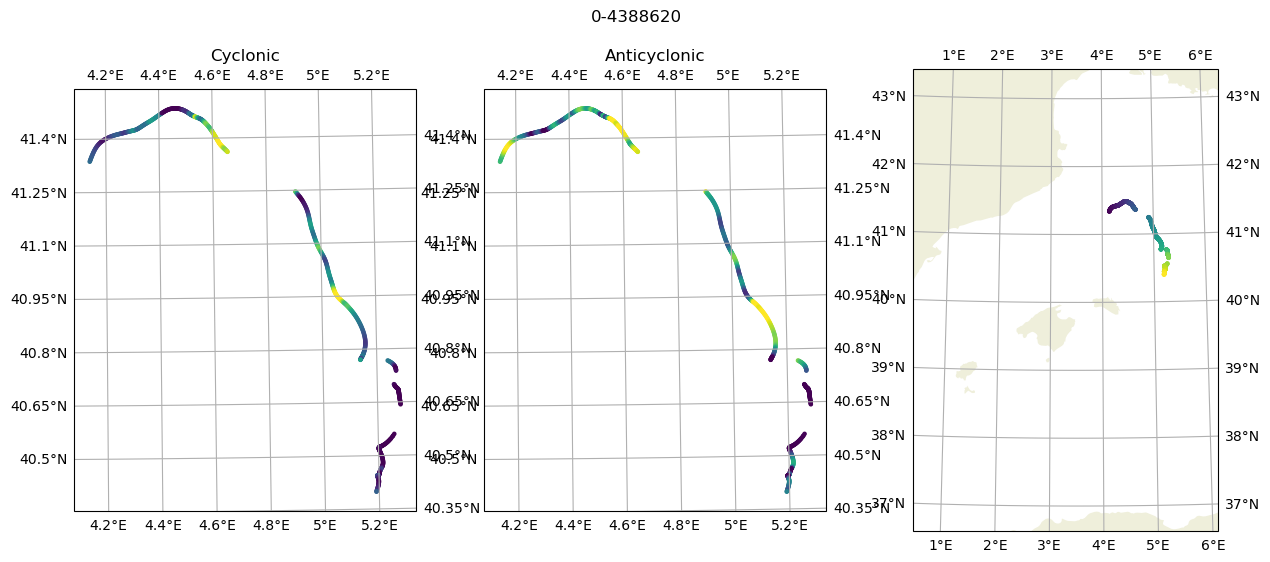

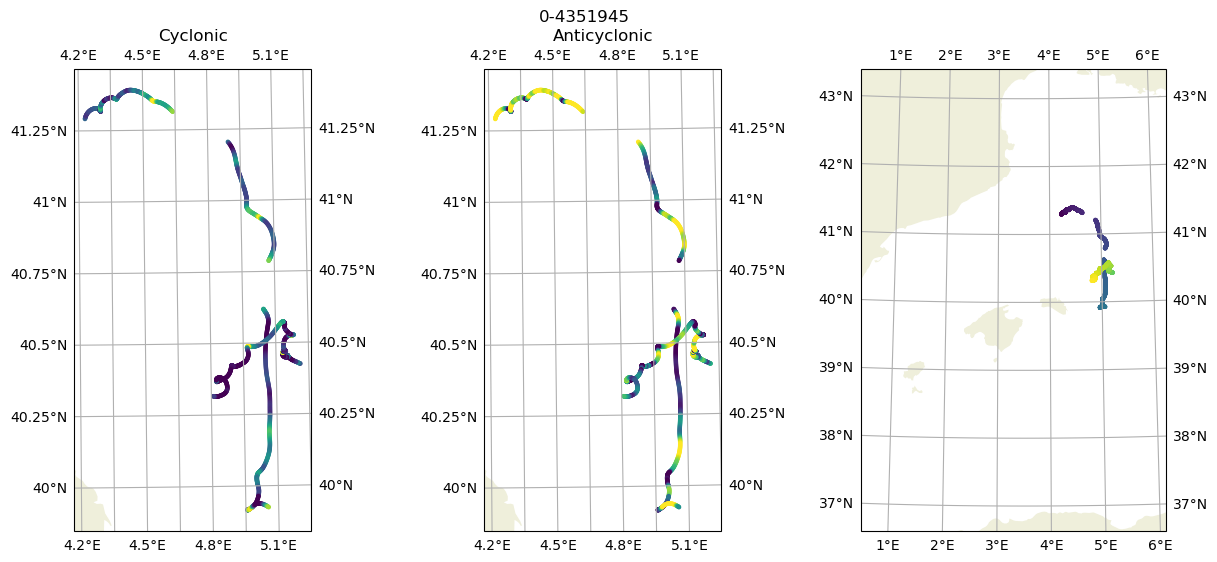

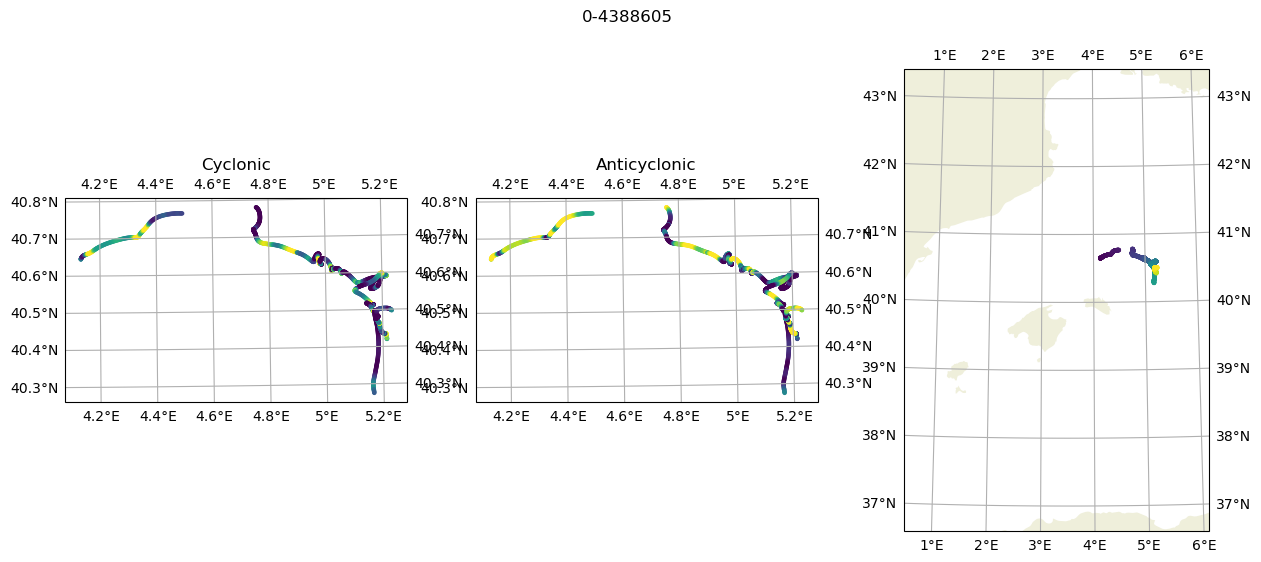

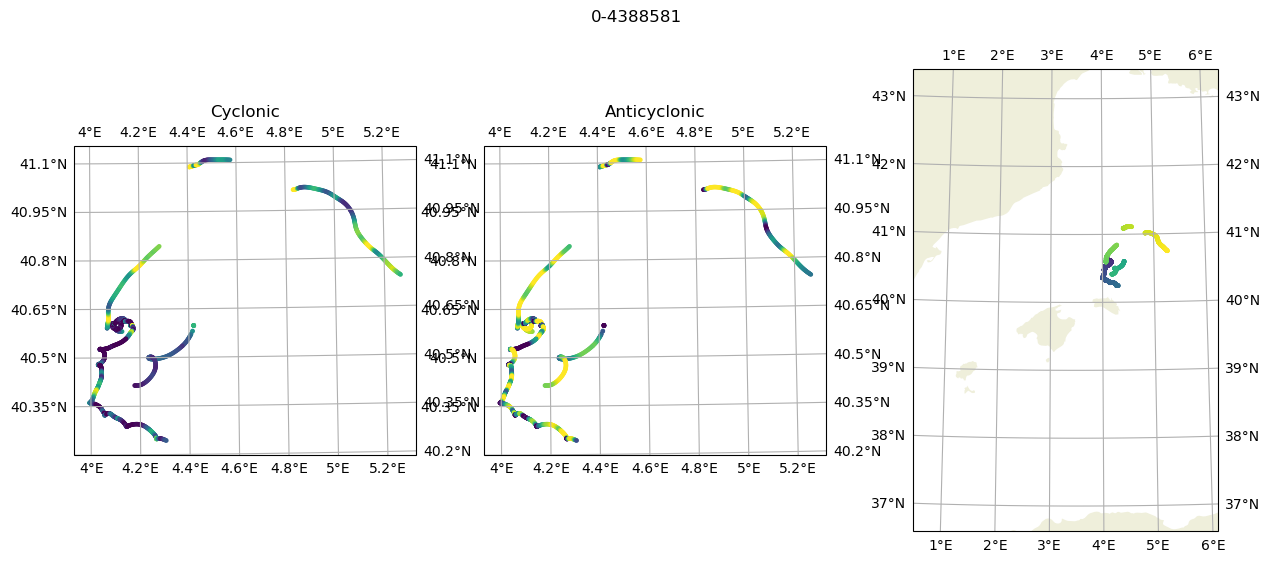

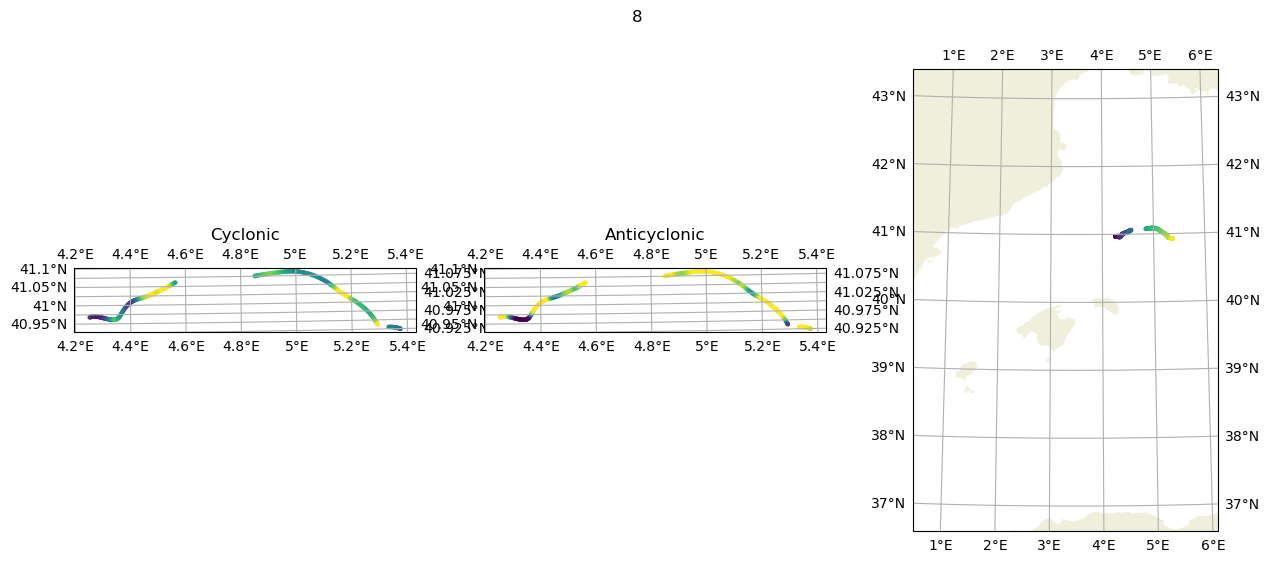

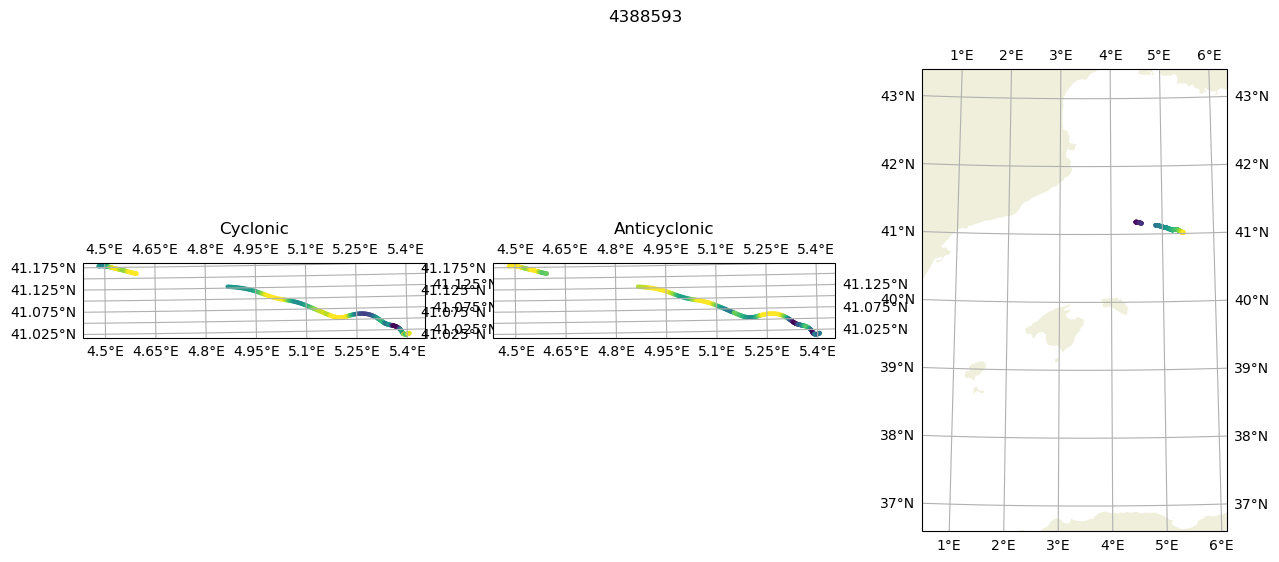

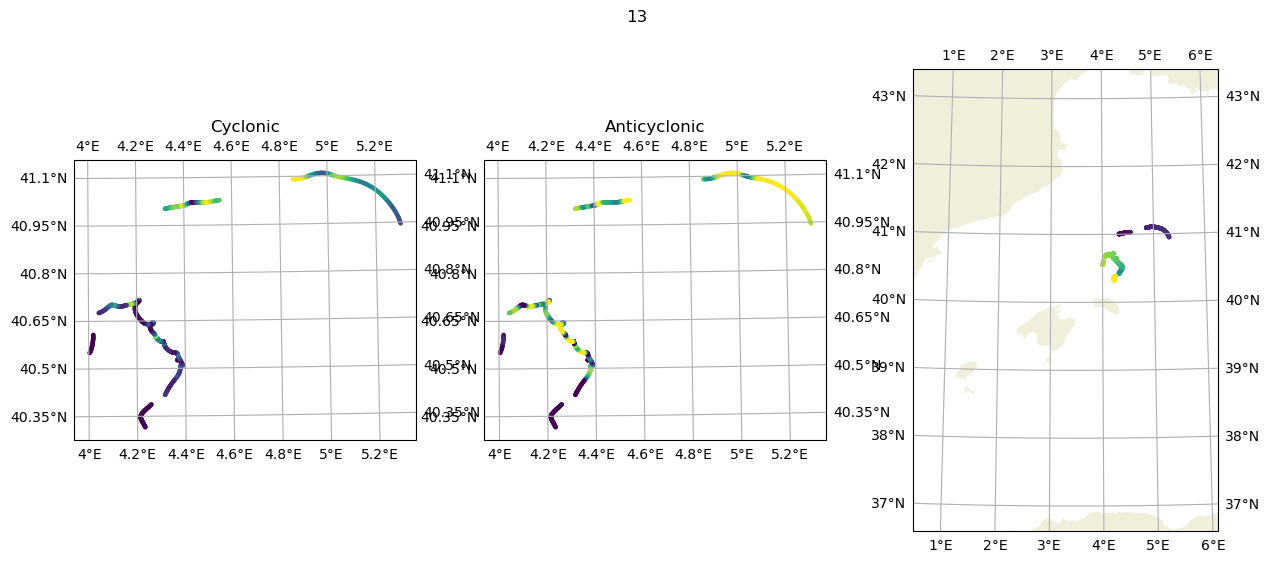

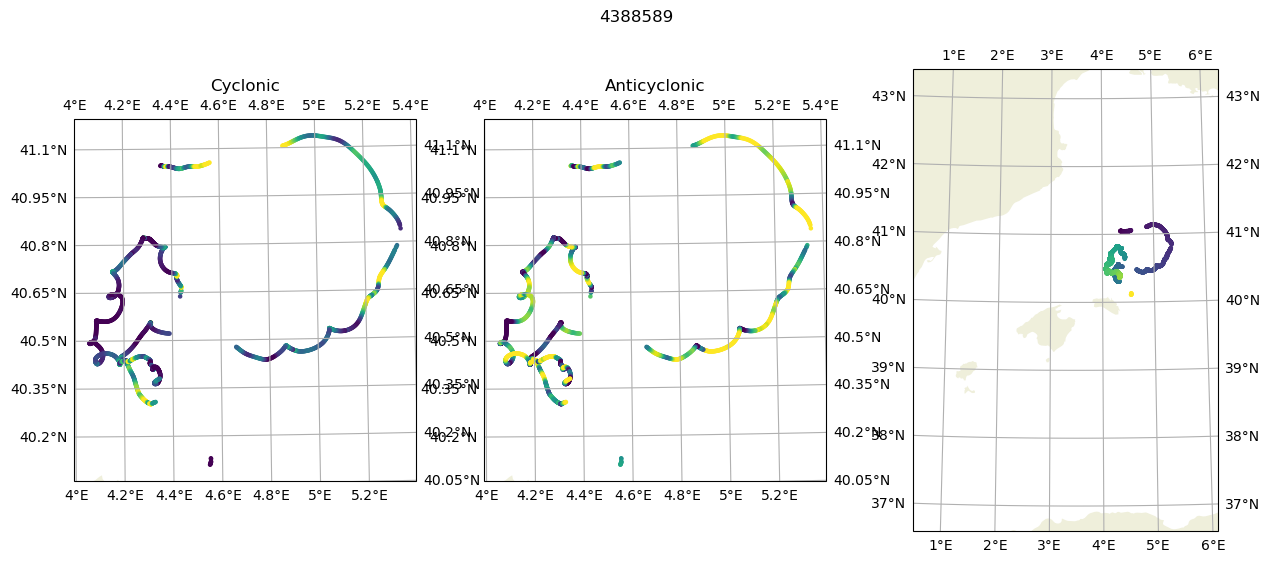

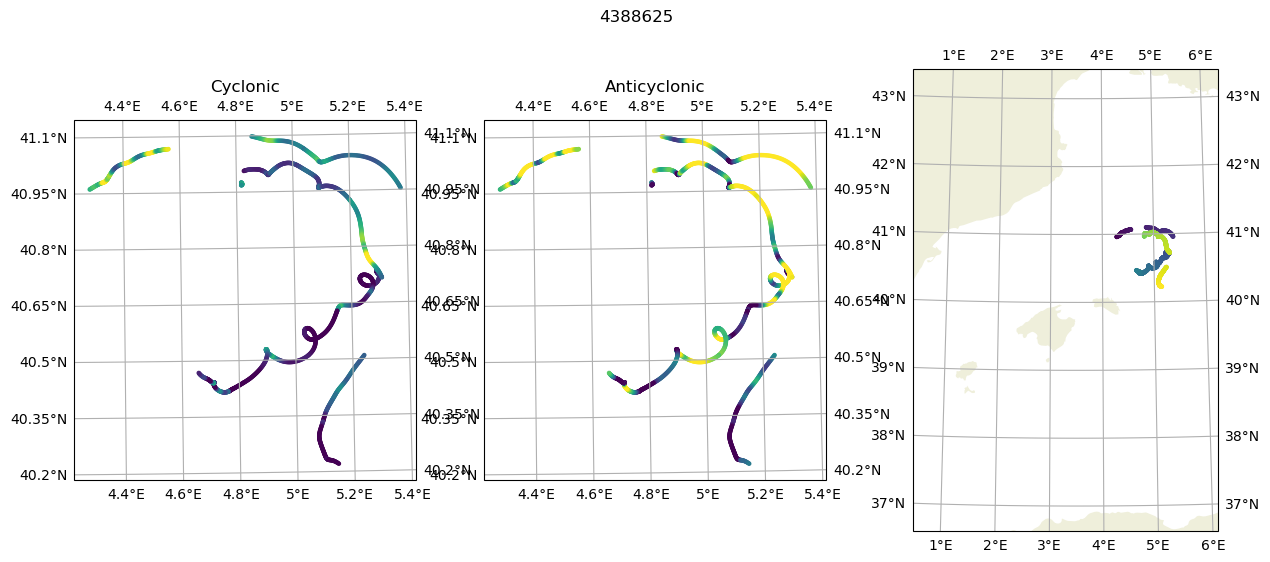

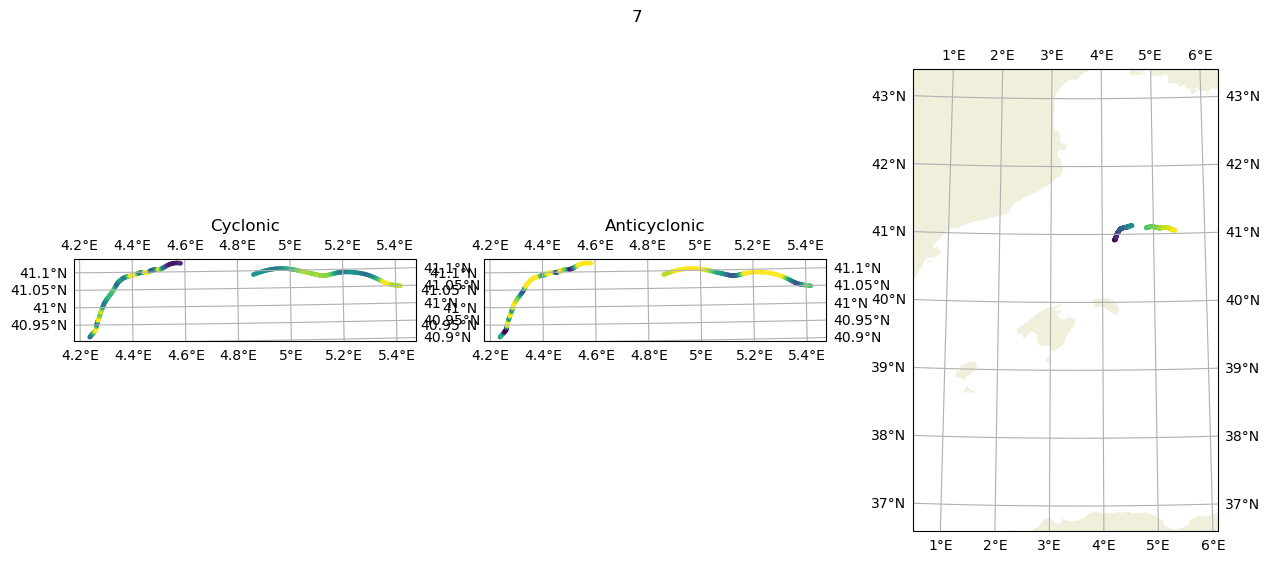

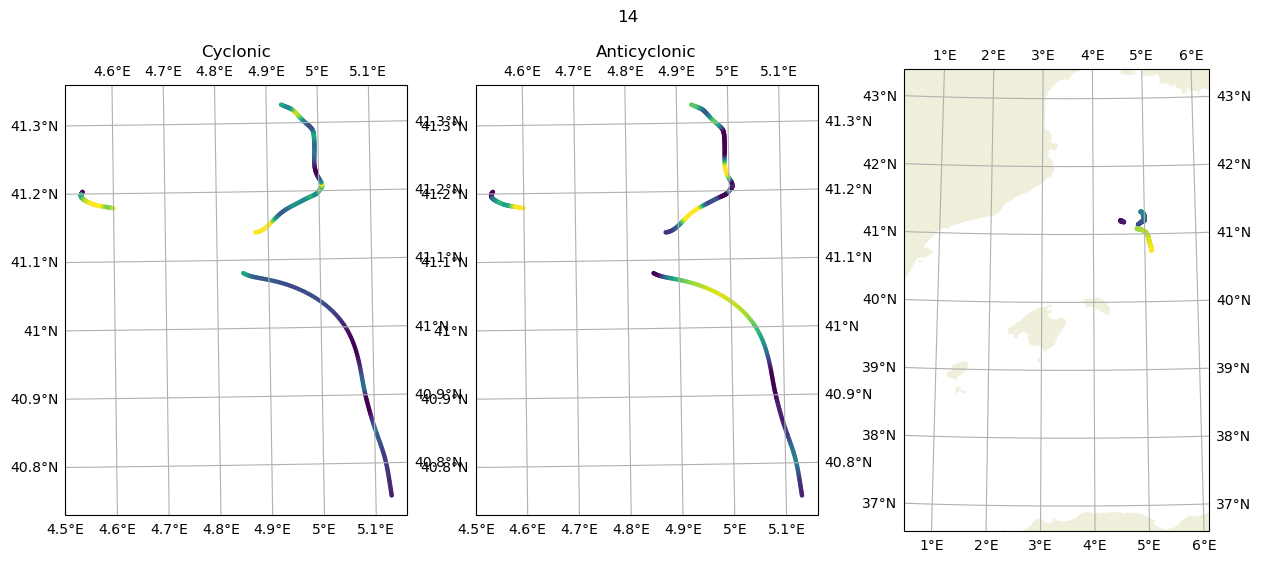

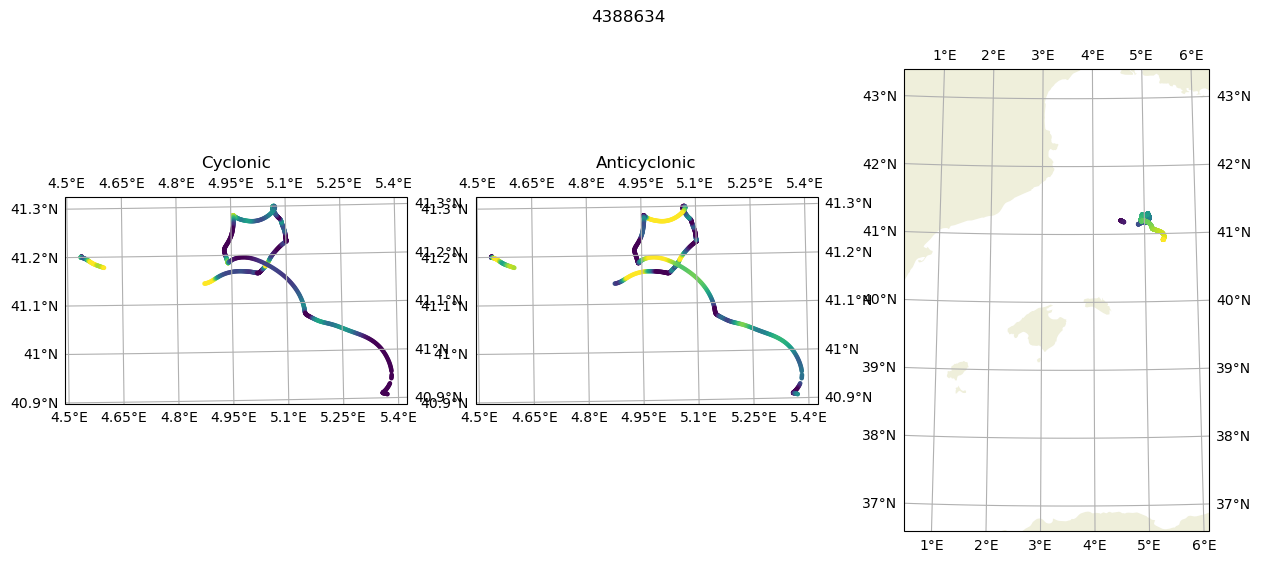

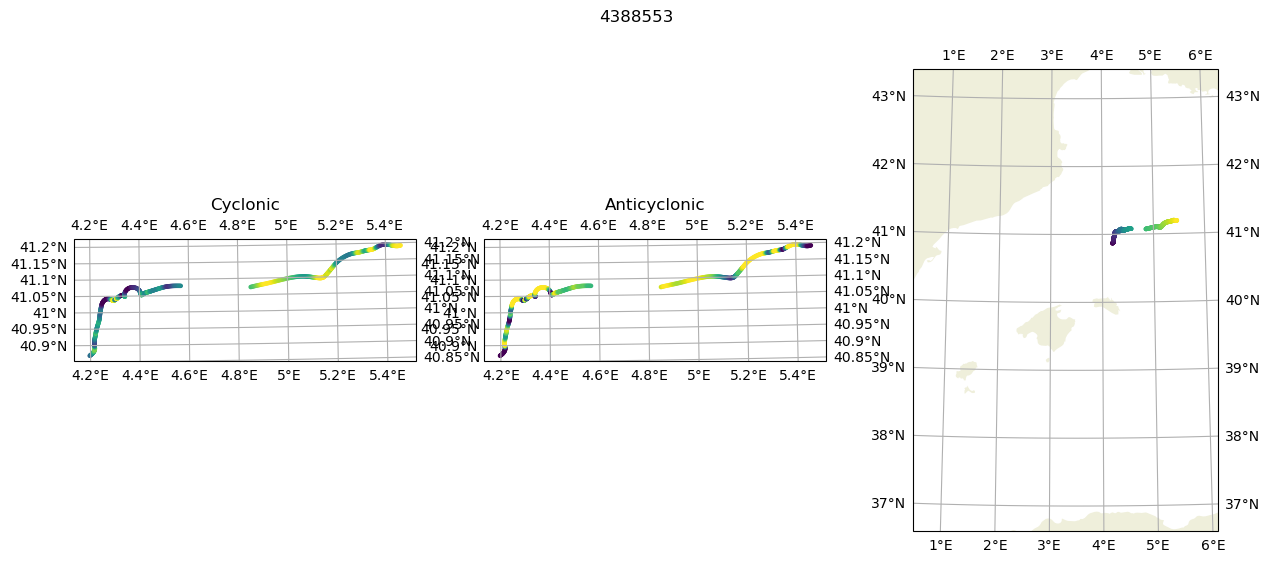

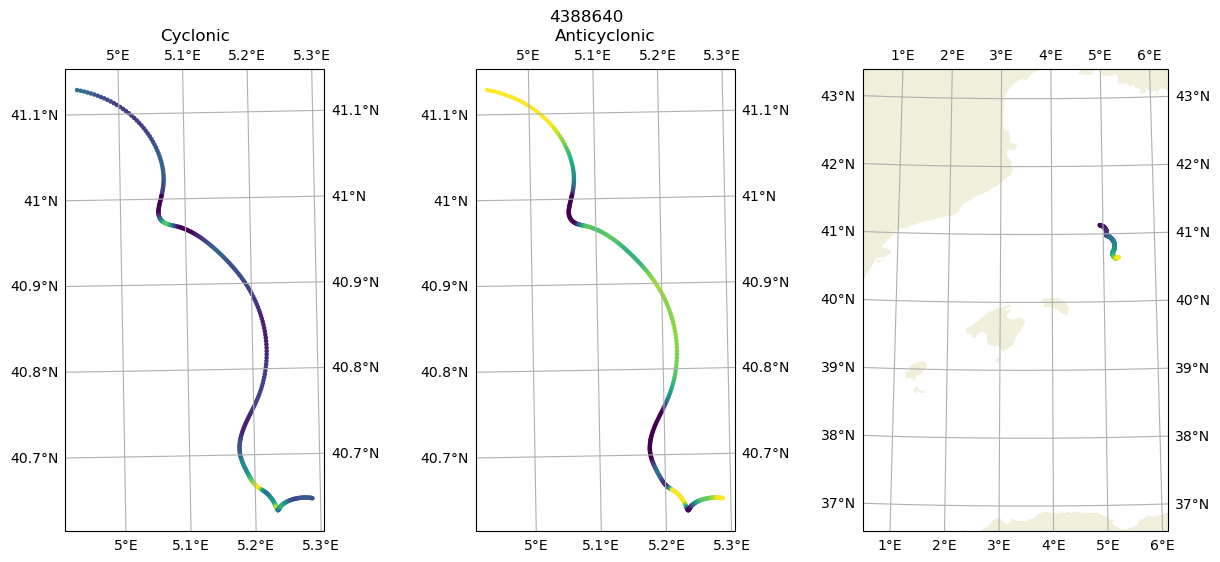

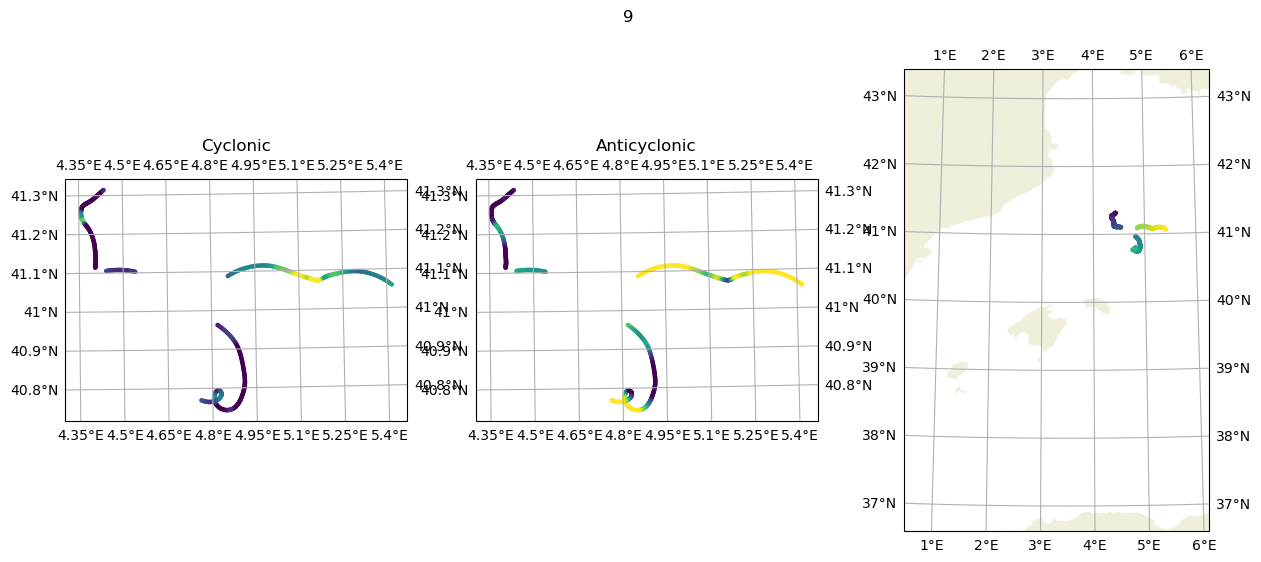

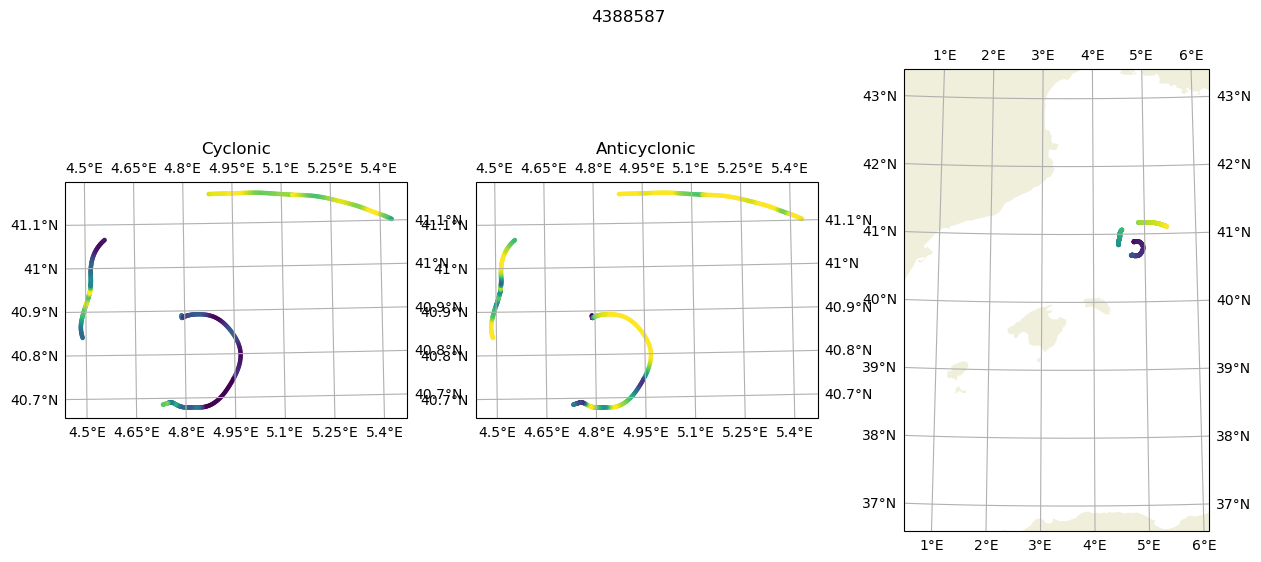

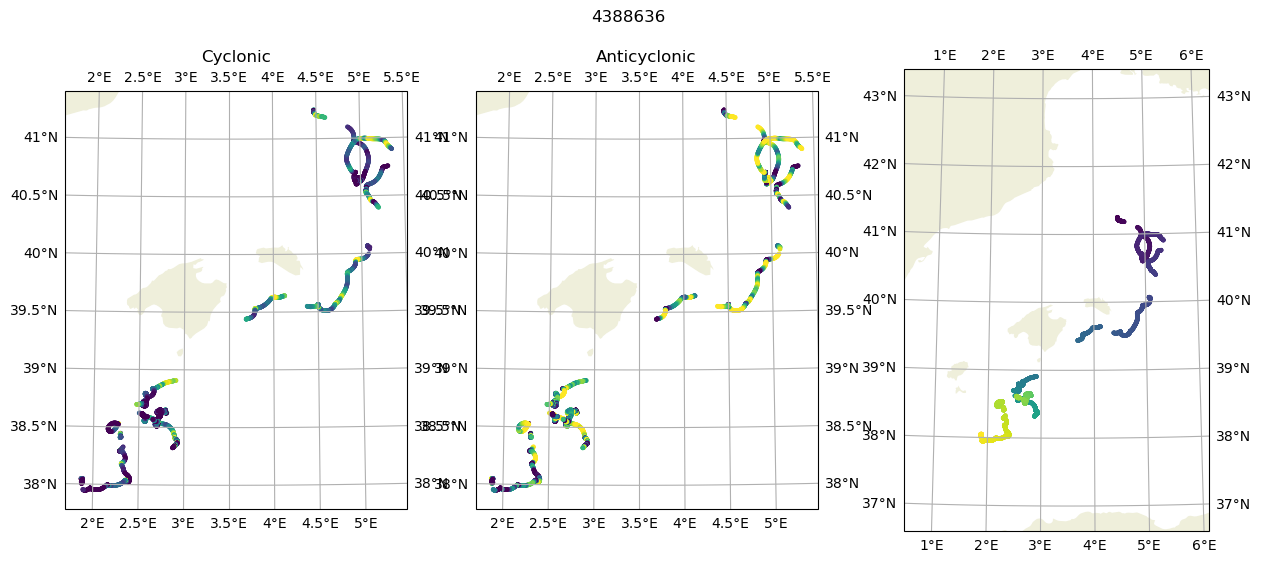

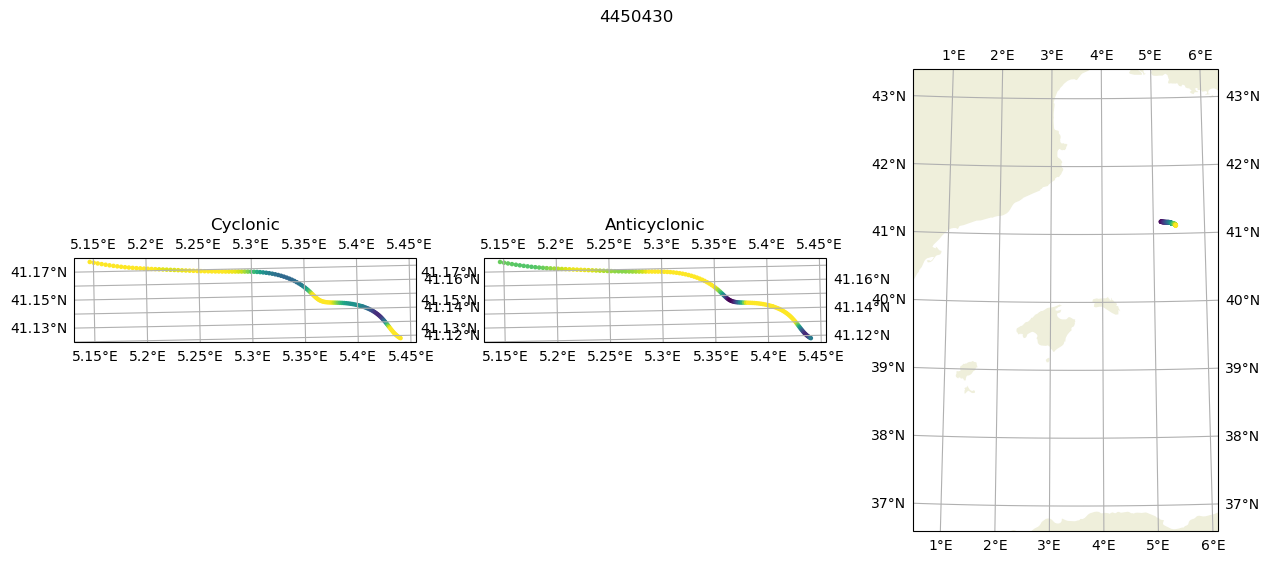

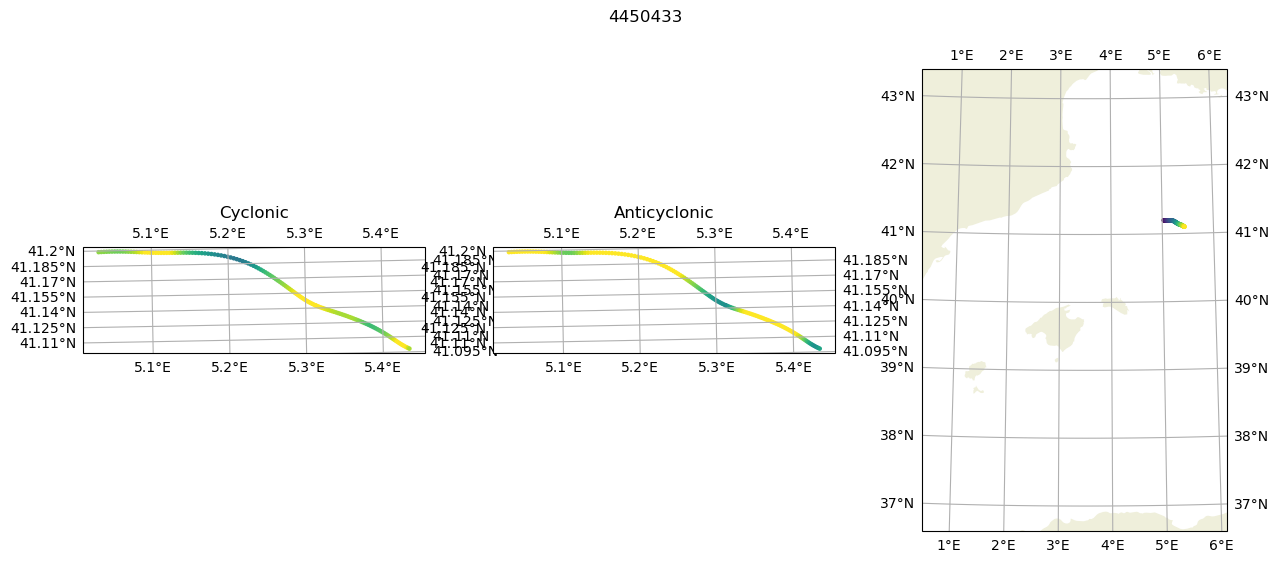

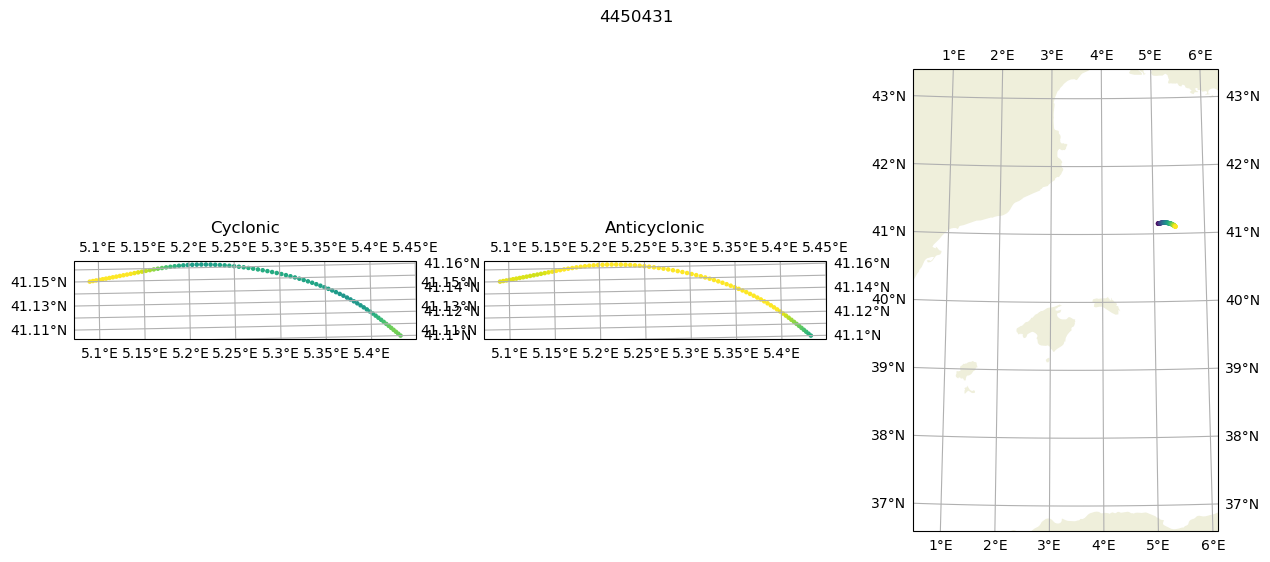

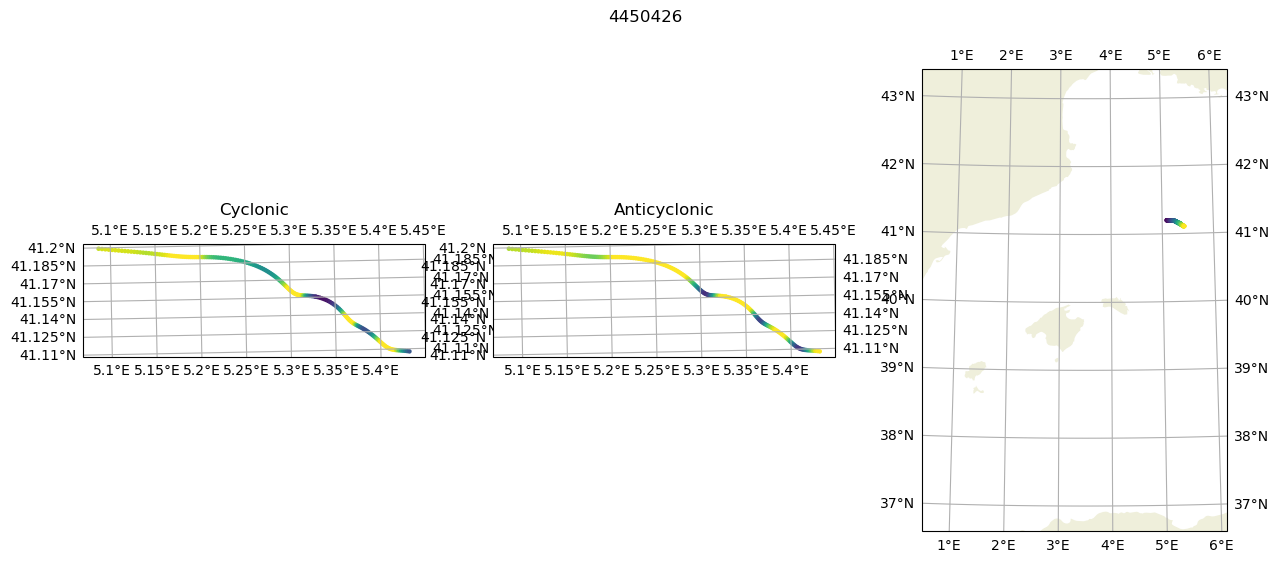

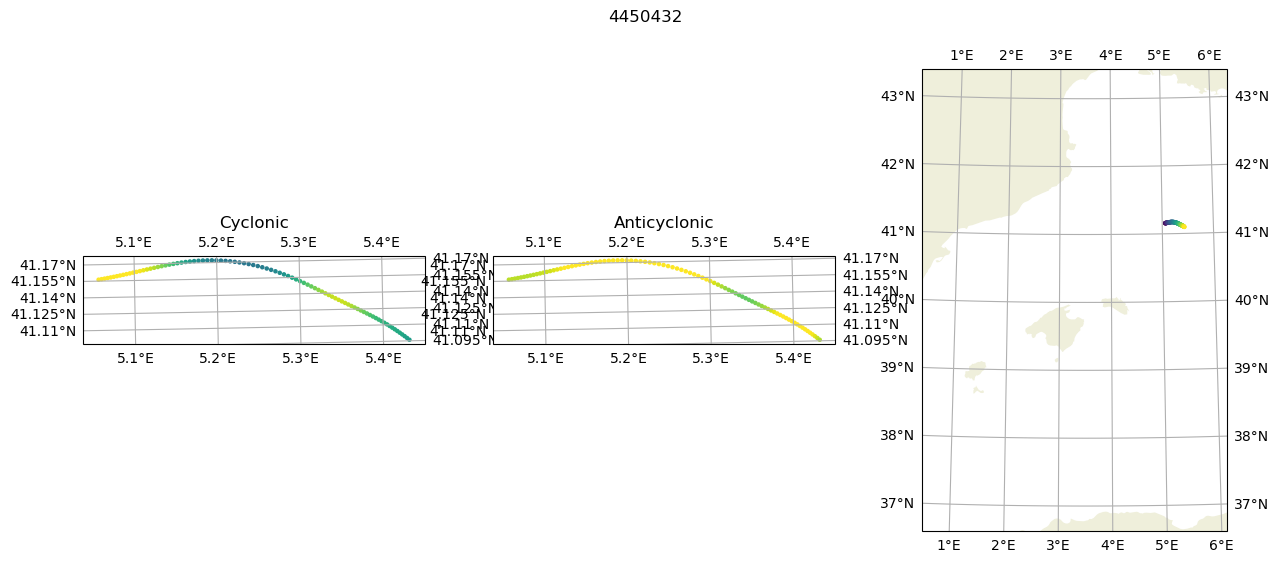

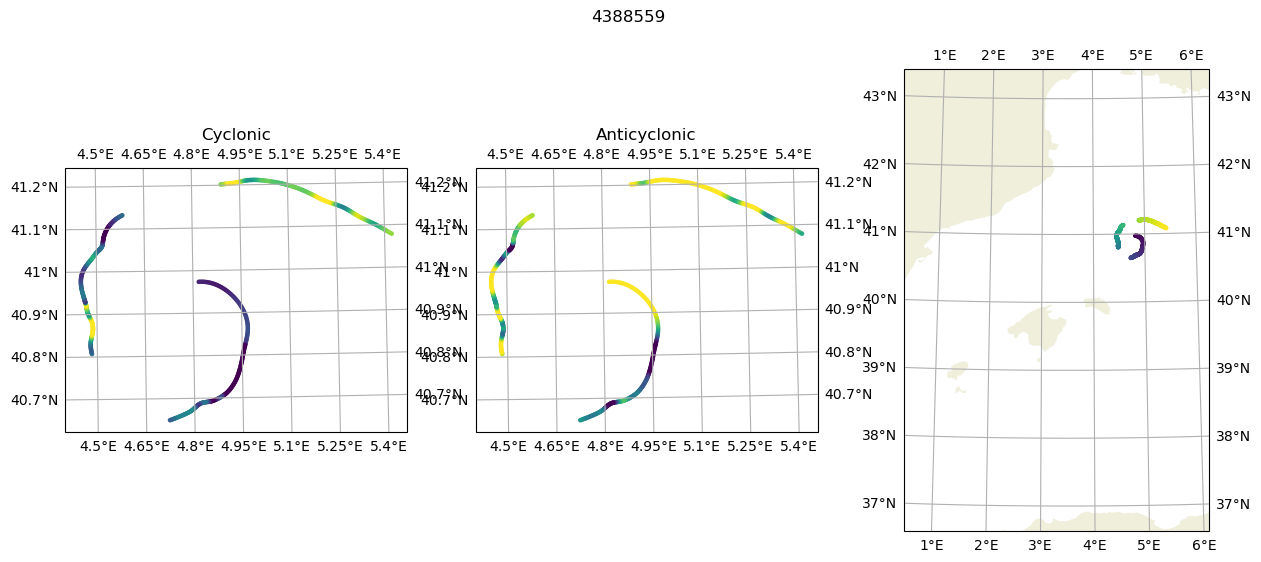

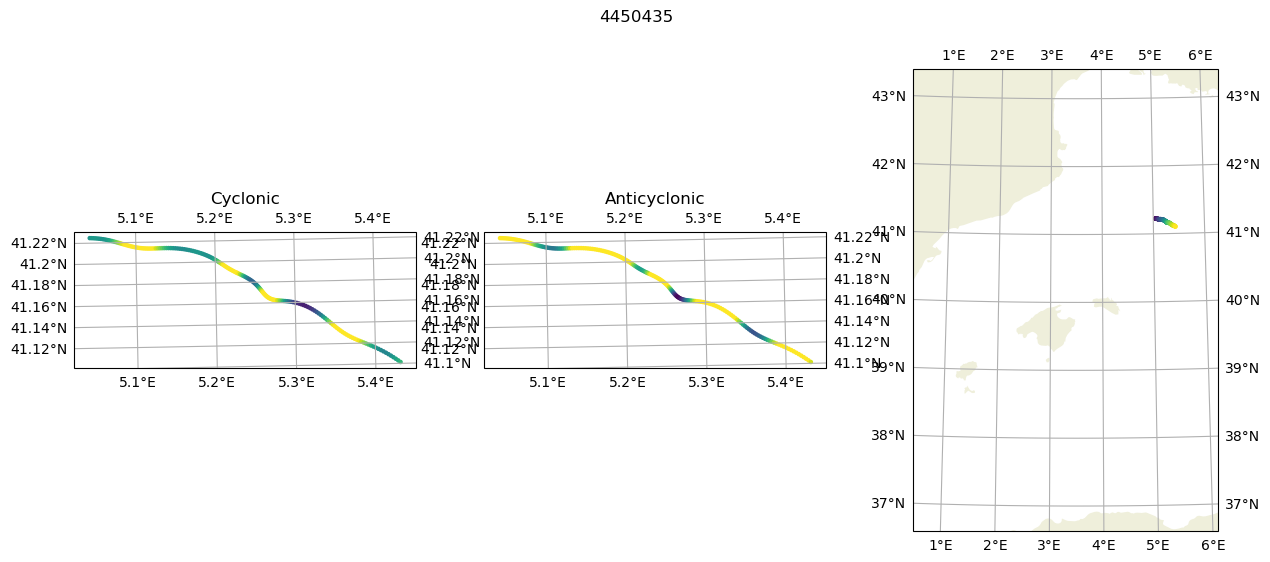

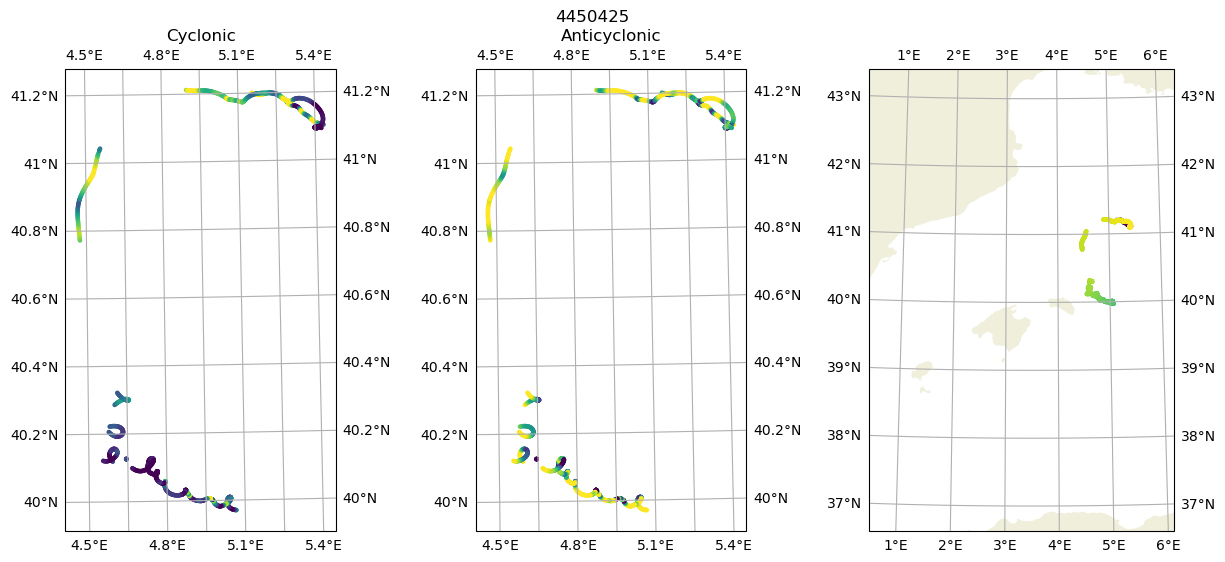

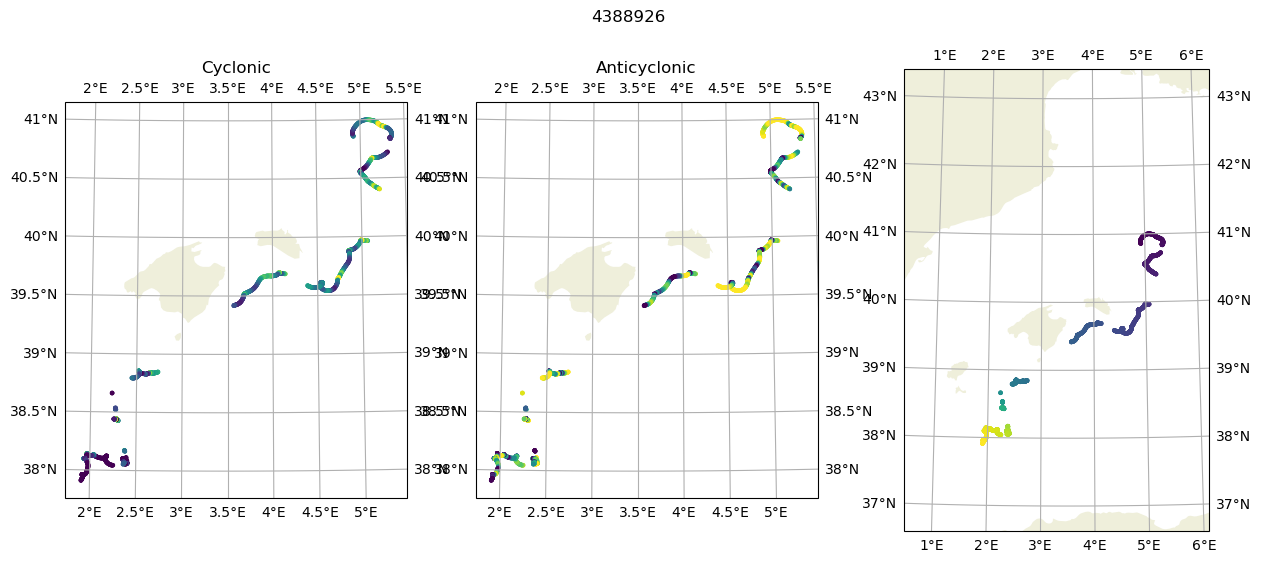

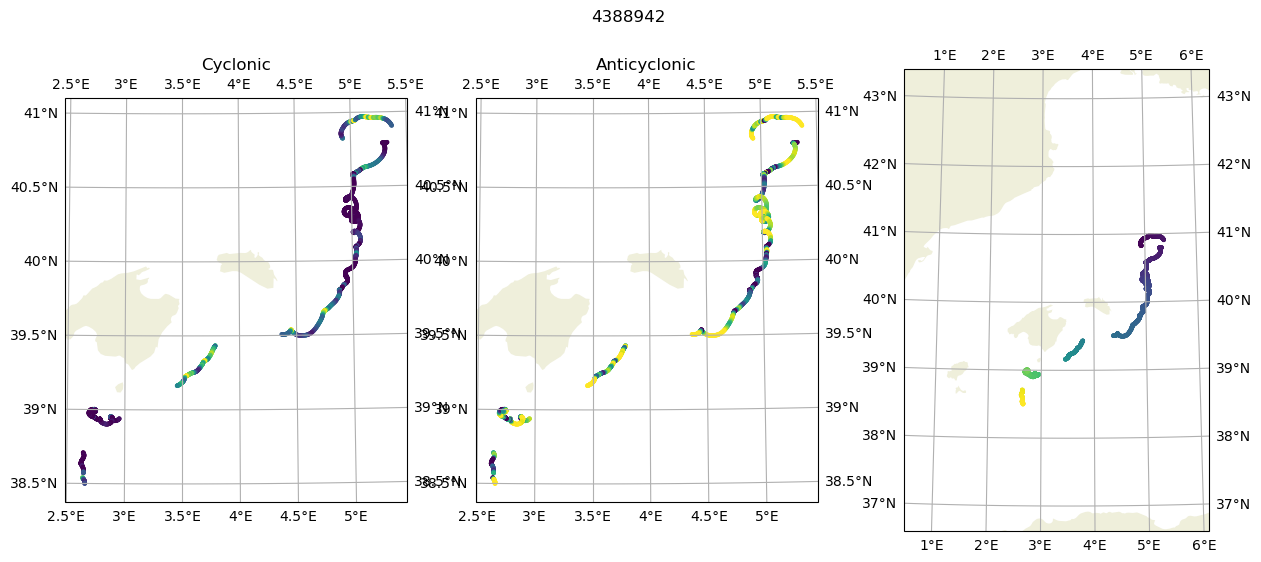

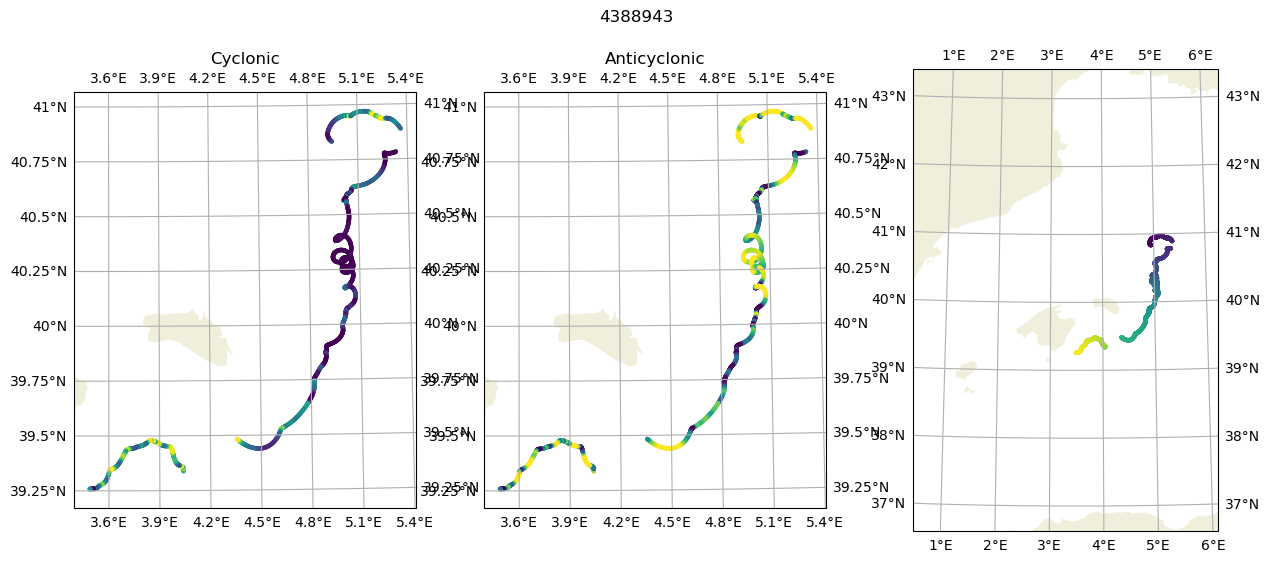

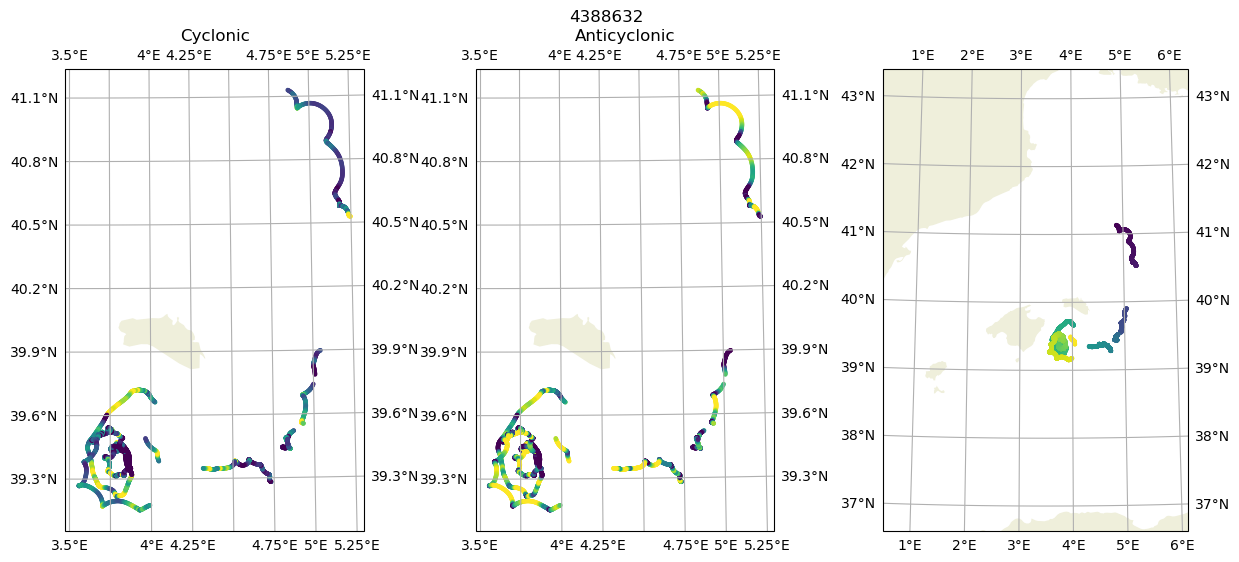

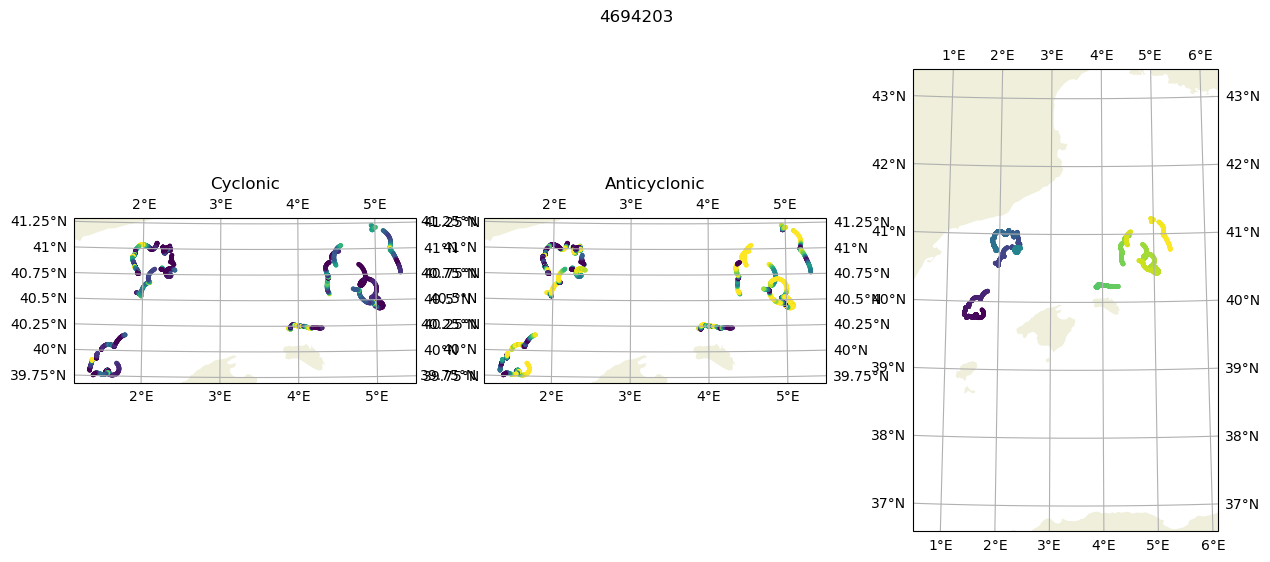

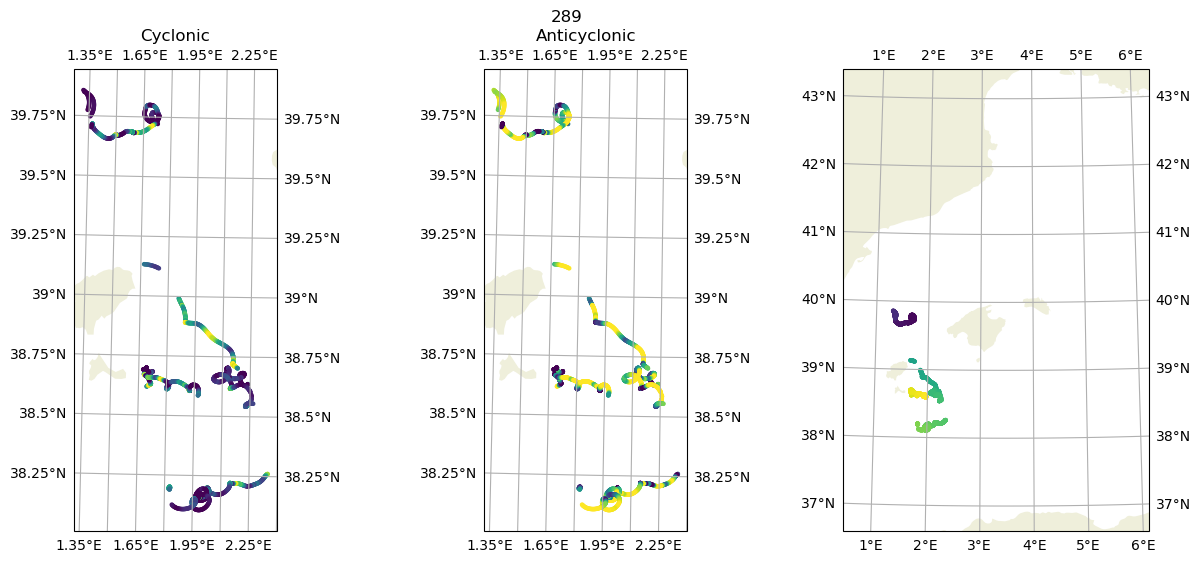

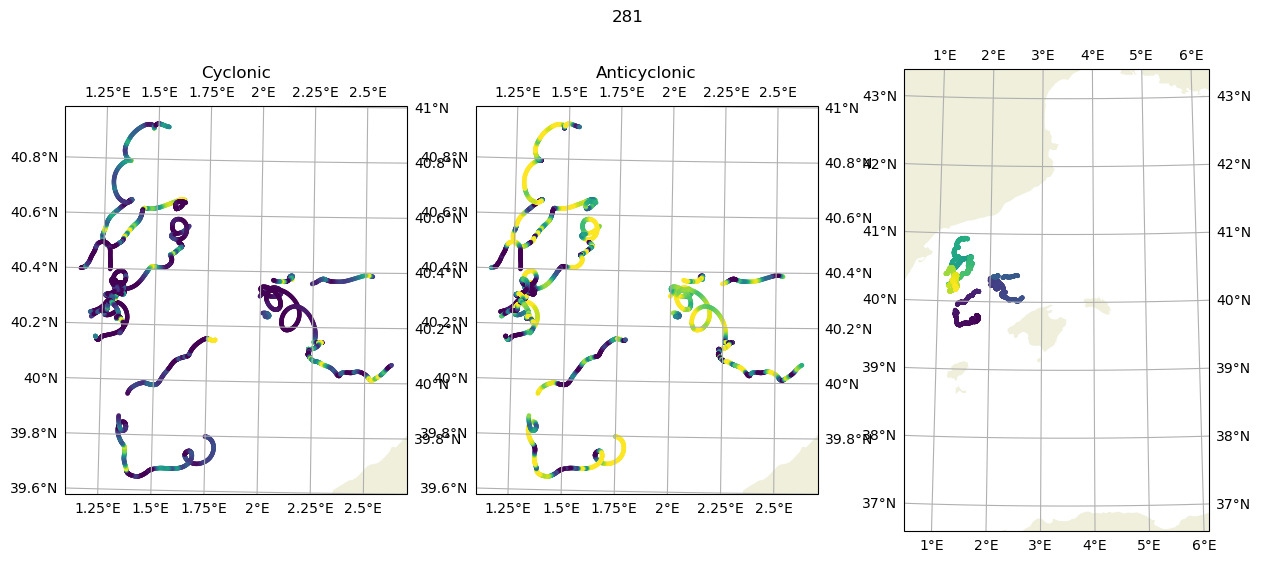

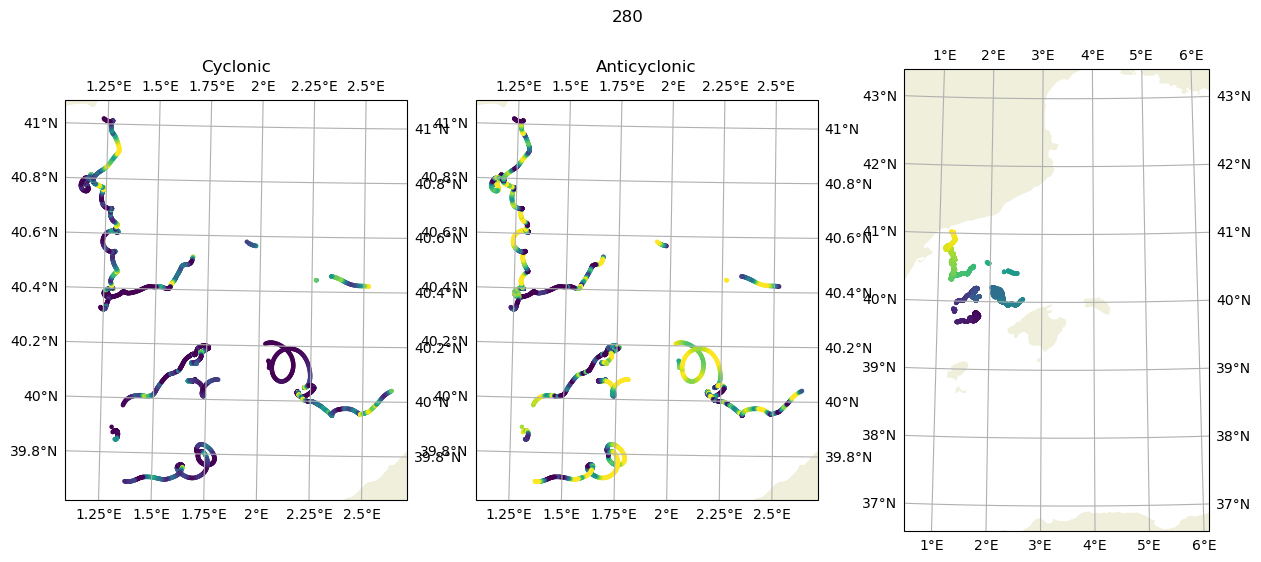

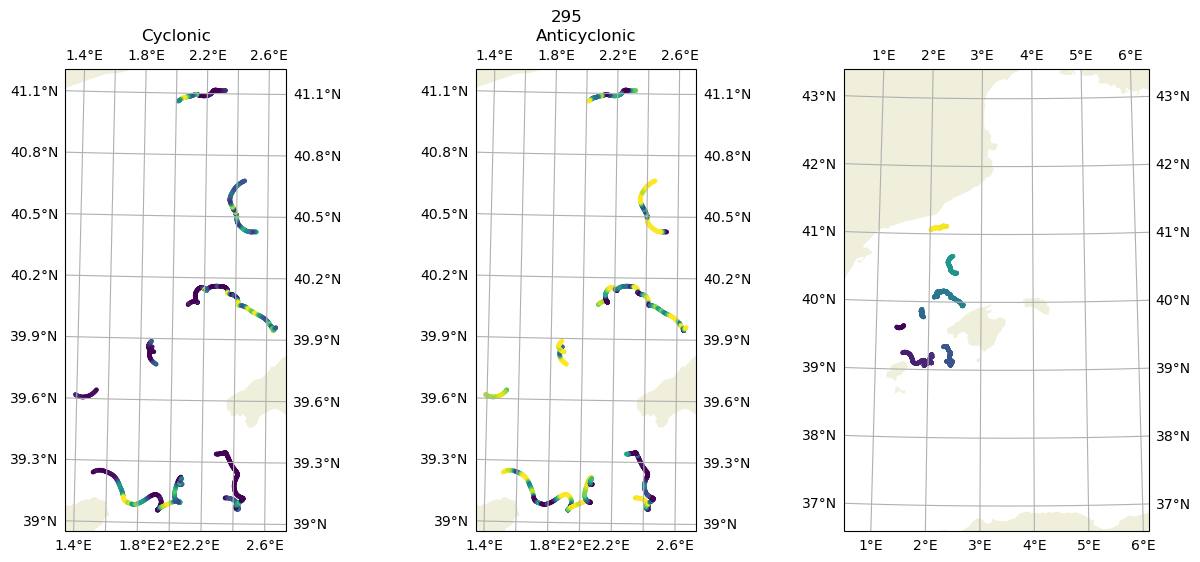

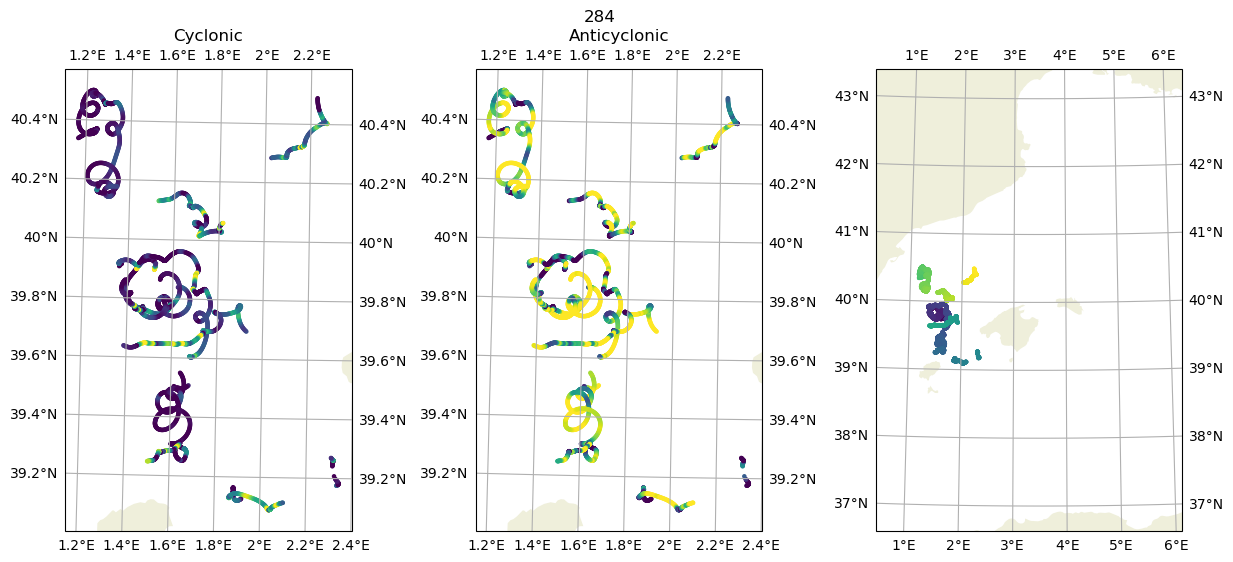

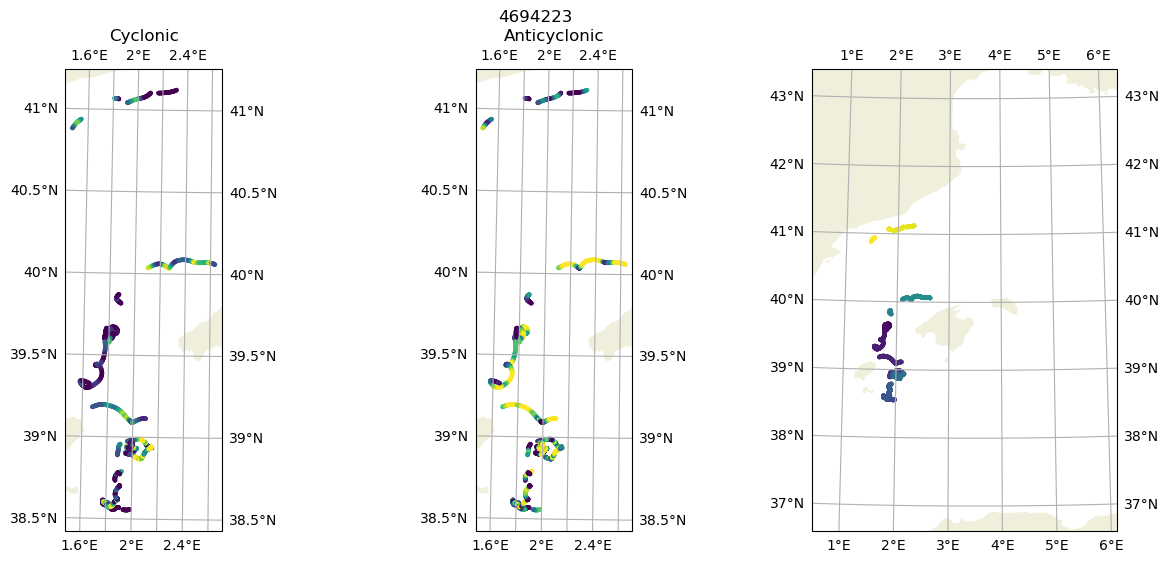

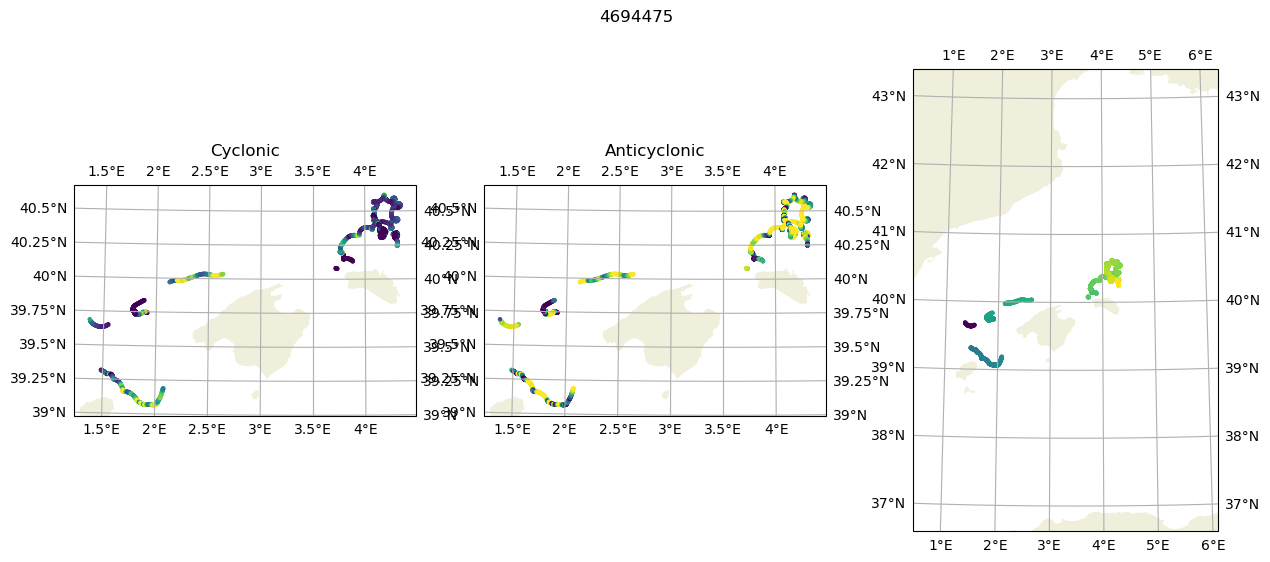

In [72]:
bbox = [0.5, 6.1, 36.6, 43.4]

for id_ in dffc.drifter_id.unique():
    df_ = dff[dff.drifter_id == id_]
    fig = plt.figure(figsize=(15,6))
    
    ax = fig.add_subplot(1, 3, 1, projection=ccrs.Orthographic(3.5, 40.5))
    df_.plot.scatter('longitude', 'latitude', marker='.', ax=ax,transform=crs, color=df_.DD_cyclo, vmin = 0, vmax = 1)
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)
    ax.set_title('Cyclonic')
    
    ax = fig.add_subplot(1, 3, 2, projection=ccrs.Orthographic(3.5, 40.5))#, c=dffc.drifter_id)  
    df_.plot.scatter('longitude', 'latitude', marker='.', ax=ax,transform=crs, color=df_.DD_anticyclo, vmin = 0, vmax = 1)
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)
    ax.set_title('Anticyclonic')
    
    ax = fig.add_subplot(1, 3, 3, projection=ccrs.Orthographic(3.5, 40.5))#, c=dffc.drifter_id)  
    df_.plot.scatter('longitude', 'latitude', marker='.', ax=ax,transform=crs, color=df_.datetime)
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)
    ax.set_extent(bbox)
    
    fig.suptitle(id_)

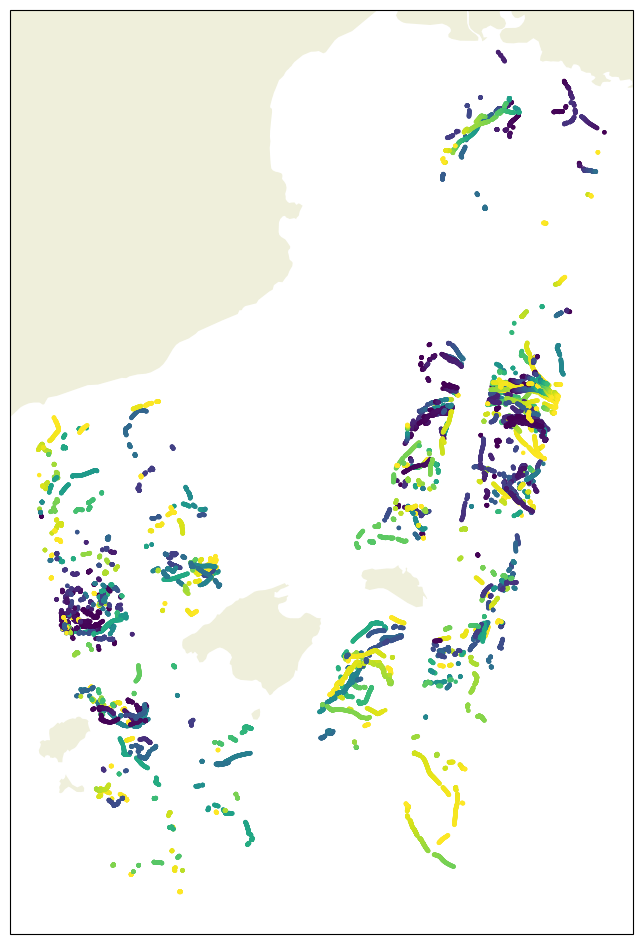

In [79]:
dffc = dff[dff.DD_cyclo>dff.DD_cyclo.quantile(0.8)]
fig = plt.figure(figsize=(10,12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(3.5, 40.5))
for id_ in dffc.drifter_id.unique():
    df_ = dffc[dffc.drifter_id == id_]
    df_.plot.scatter('longitude', 'latitude', marker='.', ax=ax,transform=crs, c=df_.datetime)  
ax.add_feature(cfeature.LAND,)


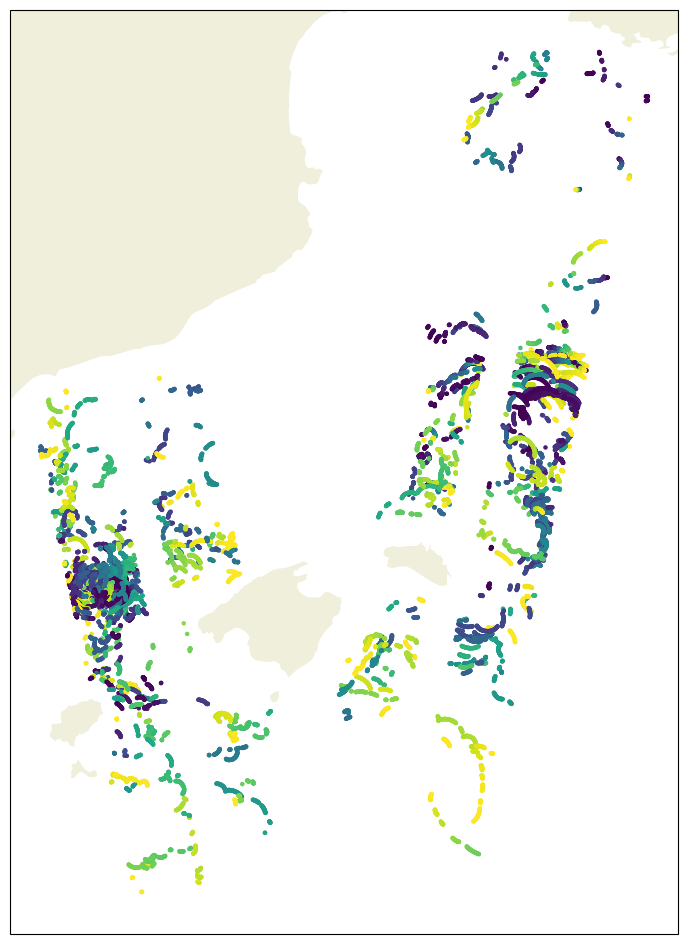

In [80]:
dffa = dff[dff.DD_anticyclo>dff.DD_anticyclo.quantile(0.8)]
fig = plt.figure(figsize=(10,12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(3.5, 40.5))
for id_ in dffa.drifter_id.unique():
    df_ = dffa[dffa.drifter_id == id_]
    df_.plot.scatter('longitude', 'latitude', marker='.', ax=ax,transform=crs, color=df_.datetime )#, c=dffc.drifter_id)  
ax.add_feature(cfeature.LAND,)
